In [122]:
# load the haberman dataset and summarize the shape
from pandas import read_csv
import matplotlib.pyplot as plt

In [123]:
# define the location of the dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/haberman.csv'

In [124]:
# load the dataset
df = read_csv(url, header=None)

In [125]:
# summarize shape
print(df.shape)

(306, 4)


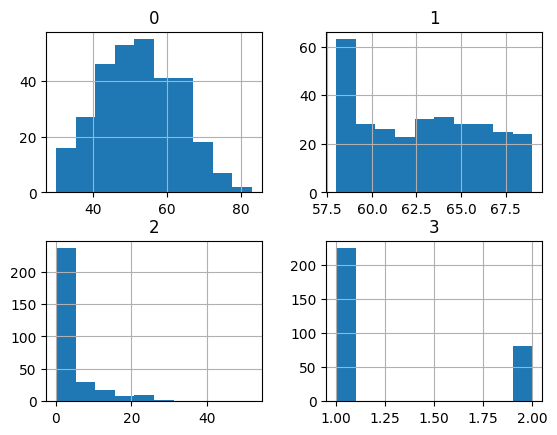

In [126]:
# plot histograms
df.hist()
plt.show()

In [127]:
df.head()

,0,1,2,3
0,30,64,1,1
1,30,62,3,1
2,30,65,0,1
3,31,59,2,1
4,31,65,4,1


In [128]:
df.describe()

,0,1,2,3
count,306.000000,306.000000,306.000000,306.000000
mean,52.457516,62.852941,4.026144,1.264706
std,10.803452,3.249405,7.189654,0.441899
min,30.000000,58.000000,0.000000,1.000000
25%,44.000000,60.000000,0.000000,1.000000
50%,52.000000,63.000000,1.000000,1.000000
75%,60.750000,65.750000,4.000000,2.000000
max,83.000000,69.000000,52.000000,2.000000


In [129]:
df.value_counts(3)

3
1    225
2     81
Name: count, dtype: int64

We can see that values vary with different means and standard deviations, perhaps some normalization or standardization would be required prior to modeling.

It may be helpful to know how imbalanced the dataset actually is.

In [130]:
from collections import Counter

In [131]:
columns = ['age', 'year', 'nodes', 'class']
# load the csv file as a data frame
dataframe = read_csv(url, header=None, names=columns)
# summarize the class distribution
target = dataframe['class'].values
counter = Counter(target)
for k,v in counter.items():
	per = v / len(target) * 100
	print('Class=%d, Count=%d, Percentage=%.3f%%' % (k, v, per))

Class=1, Count=225, Percentage=73.529%
Class=2, Count=81, Percentage=26.471%


We can see that class 1 for survival has the most examples at 225, or about 74 percent of the dataset. We can see class 2 for non-survival has fewer examples at 81, or about 26 percent of the dataset.

# Neural Network Learning Dynamics

Given that the dataset is small, a small batch size is probably a good idea, e.g. 16 or 32 rows. Using the Adam version of stochastic gradient descent is a good idea when getting started as it will automatically adapt the learning rate and works well on most datasets.

Before we evaluate models in earnest, it is a good idea to review the learning dynamics and tune the model architecture and learning configuration until we have stable learning dynamics, then look at getting the most out of the model.

We can do this by using a simple train/test split of the data and review plots of the learning curves. This will help us see if we are over-learning or under-learning; then we can adapt the configuration accordingly.

In [132]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [133]:
# split into input and output columns
X, y = df.values[:, :-1], df.values[:, -1]
# split into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=3)

In [134]:
# ensure all data are floating point values
X = X.astype('float32')
# encode strings to integer
y = LabelEncoder().fit_transform(y)

In [135]:
from keras.models import Sequential
from keras.layers import Dense

In [136]:
# determine the number of input features
n_features = X.shape[1]
# define model
model = Sequential()
model.add(Dense(10, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy')

c:\Users\alexandre.karneff\Documents\GitHub\alexandre.karneff\envWorkshop\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


We will fit the model for 200 training epochs (chosen arbitrarily) with a batch size of 16 because it is a small dataset.

In [137]:
# fit the model
history = model.fit(X_train, y_train, epochs=200, batch_size=16, verbose=0, validation_data=(X_test,y_test))

In [138]:
from sklearn.metrics import accuracy_score

In [139]:
# predict test set
yhat = model.predict(X_test)
# evaluate predictions
score = accuracy_score(y_test, yhat)
print('Accuracy: %.3f' % score)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Accuracy: 0.732


In [140]:
import matplotlib.pyplot as plt

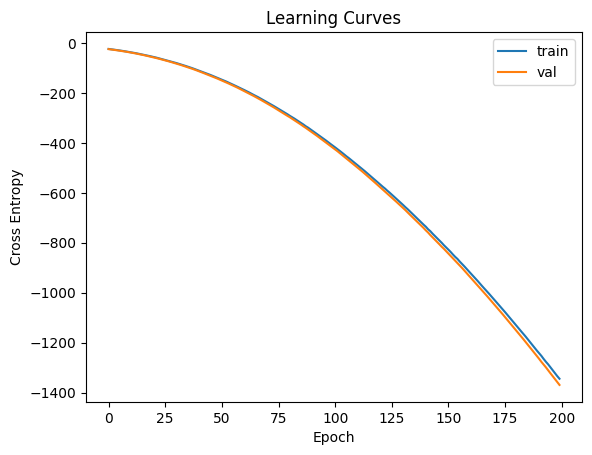

In [141]:
# plot learning curves
plt.title('Learning Curves')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.show()

# Robust Model Evaluation

The k-fold cross-validation procedure can provide a more reliable estimate of MLP performance, although it can be very slow.

In [142]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

In [143]:
# load the dataset
path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/haberman.csv'
df = read_csv(path, header=None)
# split into input and output columns
X, y = df.values[:, :-1], df.values[:, -1]
# ensure all data are floating point values
X = X.astype('float32')
# encode strings to integer
y = LabelEncoder().fit_transform(y)
# prepare cross validation
kfold = StratifiedKFold(10)
# enumerate splits
scores = list()
for train_ix, test_ix in kfold.split(X, y):
	# split data
	X_train, X_test, y_train, y_test = X[train_ix], X[test_ix], y[train_ix], y[test_ix]
	# determine the number of input features
	n_features = X.shape[1]
	# define model
	model = Sequential()
	model.add(Dense(10, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
	model.add(Dense(1, activation='sigmoid'))
	# compile the model
	model.compile(optimizer='adam', loss='binary_crossentropy')
	# fit the model
	model.fit(X_train, y_train, epochs=200, batch_size=16, verbose=0)
	# predict test set
	yhat = (model.predict(X_test) > 0.5).astype(int)
	# evaluate predictions
	score = accuracy_score(y_test, yhat)
	print('>%.3f' % score)
	scores.append(score)
# summarize all scores
print('Mean Accuracy: %.3f (%.3f)' % (np.mean(scores), np.std(scores)))

c:\Users\alexandre.karneff\Documents\GitHub\alexandre.karneff\envWorkshop\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
>0.774


c:\Users\alexandre.karneff\Documents\GitHub\alexandre.karneff\envWorkshop\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
>0.774


c:\Users\alexandre.karneff\Documents\GitHub\alexandre.karneff\envWorkshop\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
>0.800


c:\Users\alexandre.karneff\Documents\GitHub\alexandre.karneff\envWorkshop\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
>0.767


c:\Users\alexandre.karneff\Documents\GitHub\alexandre.karneff\envWorkshop\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
>0.700
Mean Accuracy: 0.755 (0.032)


Running the example reports the model performance each iteration of the evaluation procedure and reports the mean and standard deviation of classification accuracy at the end of the run.

This confirms our expectation that the base model configuration may work better than a naive model for this dataset

# Final Model and Make Predictions

In [146]:
# fit a final model and make predictions on new data for the haberman dataset
# load the dataset
path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/haberman.csv'
df = read_csv(path, header=None)
# split into input and output columns
X, y = df.values[:, :-1], df.values[:, -1]
# ensure all data are floating point values
X = X.astype('float32')
# encode strings to integer
le = LabelEncoder()
y = le.fit_transform(y)
# determine the number of input features
n_features = X.shape[1]
# define model
model = Sequential()
model.add(Dense(10, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy')
# fit the model
model.fit(X, y, epochs=200, batch_size=16, verbose=0)
# define a row of new data
row = np.array([[30, 64, 1]], dtype='float32')
# make prediction
yhat = (model.predict(row) > 0.5).astype(int)
# invert transform to get label for class
yhat = le.inverse_transform(yhat.flatten())
# report prediction
print('Predicted: %s' % (yhat[0]))

c:\Users\alexandre.karneff\Documents\GitHub\alexandre.karneff\envWorkshop\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted: 1


Running the example fits the model on the entire dataset and makes a prediction for a single row of new data.